#Library Imports:

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [83]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, LeaveOneOut, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [84]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [85]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Q 1. Import and understand the data:

In [86]:
#A. Import ‘signal-data.csv’ as DataFrame.
signal_data_df = pd.read_csv('/content/drive/MyDrive/DS_AIML/AIML_PGP_Code/6.Featurization, Model Selection & Tuning/Week22_Project Submission/signal-data.csv')

In [87]:
print(signal_data_df.shape)
signal_data_df.head()

(1567, 592)


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [88]:
#B. Print 5 point summary and share at least 2 observations.
signal_data_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


**Observations:**
1. Except 'Time' attributes all other are of numeric type.
2. There are outliers for multiple attributes like '4', '581', '585', '589'.
3.  Scaling is required as it seems that different attributes are on different scale.

#Q 2. Data cleansing:

In [89]:
#A. Write a for loop which will remove all the features with 20%+ Null values and impute rest with mean of the feature.
def handle_missing_values(df, null_threshold=0.2):
  null_ratios = df.isnull().mean()
  df = df.loc[:, null_ratios[null_ratios <= null_threshold].index]
  for col in df.columns:
    if df[col].dtype != 'object':
      df[col].fillna(df[col].mean(), inplace=True)
  return df
signal_data_df_rm = handle_missing_values(signal_data_df.copy())
signal_data_df_rm.shape

(1567, 560)

In [90]:
#B. Identify and drop the features which are having same value for all the rows.
if signal_data_df_rm.duplicated().sum() == 0:
  print("No duplicate rows found.")
else:
  signal_data_df_rm.drop_duplicates(inplace=True)
  print("Duplicate rows dropped.")

No duplicate rows found.


In [91]:
#C. Drop other features if required using relevant functional knowledge. Clearly justify the same.
signal_data_df_rm.drop(columns=['Time'], inplace=True)

In [92]:
signal_data_df_rm.head()

,0,1,2,3,4,5,6,7,8,9,...,577,582,583,584,585,586,587,588,589,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,14.9509,0.5005,0.0118,0.0035,2.3630,0.021458,0.016475,0.005283,99.670066,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,10.9003,0.5019,0.0223,0.0055,4.4447,0.009600,0.020100,0.006000,208.204500,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,9.2721,0.4958,0.0157,0.0039,3.1745,0.058400,0.048400,0.014800,82.860200,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,8.5831,0.4990,0.0103,0.0025,2.0544,0.020200,0.014900,0.004400,73.843200,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,10.9698,0.4800,0.4766,0.1045,99.3032,0.020200,0.014900,0.004400,73.843200,-1


In [93]:
# Calculate variance efficiently using numpy.var
variances = np.var(signal_data_df_rm.drop(['Pass/Fail'], axis=1), axis=0)
# Filter features based on variance threshold
low_variance_features = variances[variances < 1].index
signal_data_df_hv = signal_data_df_rm.drop(columns=low_variance_features)
signal_data_df_hv.shape

(1567, 227)

In [94]:
signal_data_df_hv.head()

,0,1,2,3,4,6,12,14,15,16,...,564,569,570,572,574,576,577,585,589,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,202.4396,7.9558,414.8710,10.0433,...,6.444985,21.117674,533.8500,8.95,3.0624,1.6765,14.9509,2.3630,99.670066,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,200.5470,10.1548,414.7347,9.2599,...,6.444985,21.117674,535.0164,5.92,2.0111,1.1065,10.9003,4.4447,208.204500,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,202.0179,9.5157,416.7075,9.3144,...,1.100000,68.848900,535.0245,11.21,4.0923,2.0952,9.2721,3.1745,82.860200,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,201.8482,9.6052,422.2894,9.6924,...,7.320000,25.036300,530.5682,9.33,2.8971,1.7585,8.5831,2.0544,73.843200,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,201.9424,10.5661,420.5925,10.3387,...,6.444985,21.117674,532.0155,8.83,3.1776,1.6597,10.9698,99.3032,73.843200,-1


In [95]:
print('Features ',low_variance_features, 'was dropped because its variance was below the threshold, indicating it provides low informational value.')

Features  Index(['5', '7', '8', '9', '10', '11', '13', '17', '19', '20',
       ...
       '568', '571', '573', '575', '582', '583', '584', '586', '587', '588'],
      dtype='object', length=332) was dropped because its variance was below the threshold, indicating it provides low informational value.


**Features having variance below one are droped:-** Low variance indicating it provides low informational value.

In [96]:
#D. Check for multi-collinearity in the data and take necessary action.
X = signal_data_df_hv.drop(columns=['Pass/Fail'])  # Drop the target column if necessary
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

    feature           VIF
0         0  20112.452614
1         1   8068.882119
2         2   9631.990187
3         3     96.115218
4         4  32220.058581
..      ...           ...
221     574    121.732982
222     576    600.063491
223     577     13.749269
224     585      2.076797
225     589      2.670965

[226 rows x 2 columns]


In [97]:
vif_more_than_ten = vif_data['feature'].loc[vif_data['VIF'] > 10]
signal_data_df_vif = signal_data_df_hv.drop(columns=vif_more_than_ten)
signal_data_df_vif.shape

(1567, 38)

In [98]:
signal_data_df_vif.head()

,24,41,59,129,417,418,419,429,432,433,...,520,521,523,525,555,561,569,585,589,Pass/Fail
0,751.00,4.515,-1.7264,-0.0473,5.9846,525.0965,0.0000,3.6084,26.3617,49.0013,...,1.9864,0.0,0.1094,3.1406,39.8842,42.3877,21.117674,2.3630,99.670066,-1
1,-1640.25,2.773,0.8073,-0.0946,9.0604,0.0000,368.9713,3.1595,8.4887,199.7866,...,1.6292,0.0,0.0673,3.1310,53.1836,18.1087,21.117674,4.4447,208.204500,-1
2,-1916.50,5.434,23.8245,-0.1892,5.2231,0.0000,0.0000,3.5220,18.7546,109.5747,...,2.9626,0.0,0.0751,12.1831,23.0713,24.7524,68.848900,3.1745,82.860200,1
3,-1657.25,1.279,24.3791,0.2838,7.6602,317.7362,0.0000,4.9898,76.0354,181.2641,...,2.4416,0.0,0.0977,6.7553,161.4081,62.7572,25.036300,2.0544,73.843200,-1
4,117.00,2.209,-12.2945,-0.5677,4.2178,0.0000,866.0295,3.8754,43.8119,0.0000,...,2.5512,0.0,0.0616,2.9954,70.9706,22.0500,21.117674,99.3032,73.843200,-1


**Droped the features with high Variance Inflation Factor(VIF):-** Value greater than 10, its often indicates high multicollinearity

In [139]:
#E. Make all relevant modifications on the data using both functional/logical reasoning/assumptions.

**Relavent modifications:-**
1. Fetures with null values greater than 20% are droped.
2. Features with duplicate rows are droped.
3. Features with low variance indicating it, provides low informational value are droped.
4. Features with Variance Inflation Factor(VIF) value greater than 10, its often indicates high multicollinearity are droped.

#Q 3. Data analysis & visualisation:


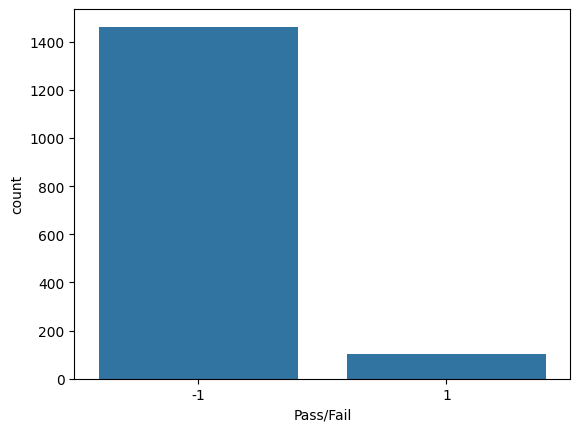

In [100]:
#A. Perform a detailed univariate Analysis with appropriate detailed comments after each analysis.
sns.countplot(x='Pass/Fail', data=signal_data_df_vif)
plt.show()

**Conclusion:-** Above plot is showing imbalance of target variable 'Pass/Fail'

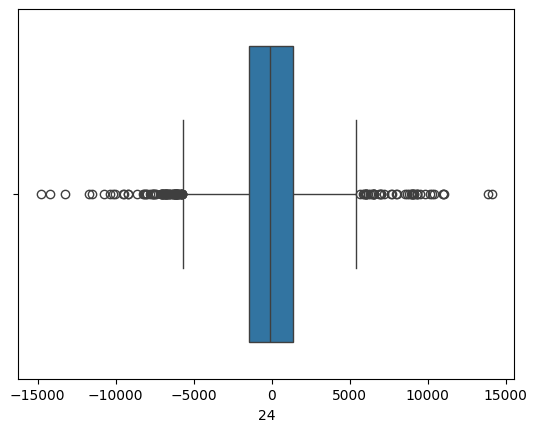

In [101]:
sns.boxplot(x='24', data=signal_data_df_vif)
plt.show()

**Conclusion:-** Above plot shows there are lot of outliers.

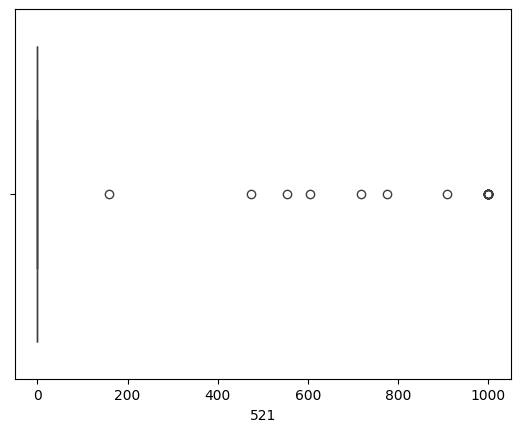

In [102]:
sns.boxplot(x='521', data=signal_data_df_vif)
plt.show()

**Conclusion:-** Above graph shows right skewed data with outliers.

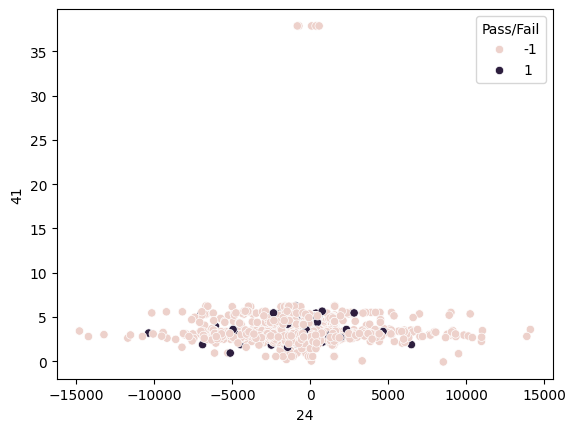

In [103]:
#B. Perform bivariate and multivariate analysis with appropriate detailed comments after each analysis
sns.scatterplot(x='24', y='41', hue='Pass/Fail', data=signal_data_df_vif)
plt.show()

**Conclusion:-** Above graphs shows that there is no corelation, in above steps using Variance Inflation Factor(VIF), multicolinearity has been removed.

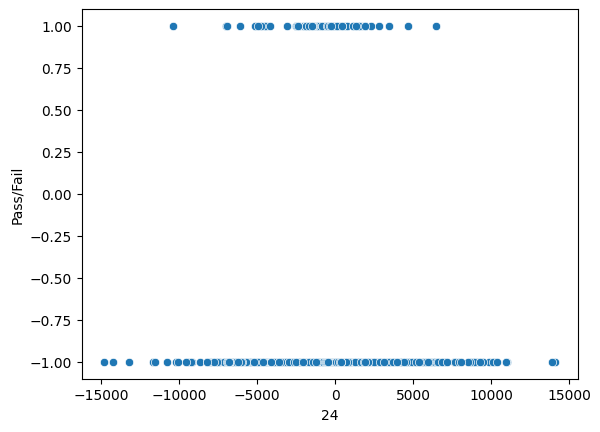

In [104]:
sns.scatterplot(x='24', y='Pass/Fail', data=signal_data_df_vif)
plt.show()

#Q 4. Data pre-processing:

In [105]:
#A. Segregate predictors vs target attributes.
X = signal_data_df_vif.drop(columns=['Pass/Fail'], axis=1)
y = signal_data_df_vif['Pass/Fail']

In [106]:
#B. Check for target balancing and fix it if found imbalanced.
print("Before UpSampling, counts of label '1': {}".format(sum(y==1)))
print("Before UpSampling, counts of label '-1': {} \n".format(sum(y==-1)))

sm = SMOTE(sampling_strategy = 1 ,k_neighbors = 5, random_state=1)
X_res, y_res = sm.fit_resample(X, y.ravel())

print("After UpSampling, counts of label '1': {}".format(sum(y_res==1)))
print("After UpSampling, counts of label '-1': {} \n".format(sum(y_res==-1)))

Before UpSampling, counts of label '1': 104
Before UpSampling, counts of label '-1': 1463 

After UpSampling, counts of label '1': 1463
After UpSampling, counts of label '-1': 1463 



**Fixed imbalance data :-** Original data is imbalance so fixed it by using oversampling of minority data.

In [107]:
#C. Perform train-test split and standardise the data or vice versa if required.
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.33, random_state=42)
scale = StandardScaler()
X_train_norm = scale.fit_transform(X_train)
X_test_norm = scale.transform(X_test)

In [108]:
#D. Check if the train and test data have similar statistical characteristics when compared with original data.
print('Original data:', X_res.describe())
print('Train data:', X_train.describe())
print('Test data:', X_test.describe())

Original data:                  24           41           59          129          417  \
count   2926.000000  2926.000000  2926.000000  2926.000000  2926.000000   
mean    -366.174516     3.380479     5.745329    -0.328014     7.825796   
std     2576.890798     1.828548     9.670456     1.021069     3.605879   
min   -14804.500000    -0.075900   -28.988200    -3.779000     2.153100   
25%    -1505.737267     2.694805    -0.449775    -0.567700     5.695684   
50%      -73.000000     3.134000     3.126350    -0.047300     7.103272   
75%     1324.937500     3.784950    10.904805     0.204333     8.665725   
max    14106.000000    37.880000   168.145500     2.458000    39.037600   

               418          419          429          432          433  ...  \
count  2926.000000  2926.000000  2926.000000  2926.000000  2926.000000  ...   
mean    306.113082   318.191588     4.134784    96.954558   213.625078  ...   
std     270.173594   298.616794     4.898647   107.996661   216.972334  

**Conclusion:-** train and test data have similar statistical characteristics like "Mean", "median", "mode", "std", "Range", "IQR", "counts", when compared with original data

#Q 5. Model training, testing and tuning:

In [109]:
#A. Use any Supervised Learning technique to train a model.
lr = LogisticRegression()
lr.fit(X_train_norm, y_train)
y_pred = lr.predict(X_test_norm)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.7370600414078675


In [110]:
#B. Use cross validation techniques.
num_folds = 50
seed = 7
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
model = LogisticRegression()
results = cross_val_score(model, X_res, y_res, cv=kfold)
print(results)
print("KFold cross-validation accuracy: ", results.mean()*100.0)

[0.6779661  0.71186441 0.71186441 0.6440678  0.74576271 0.74576271
 0.69491525 0.72881356 0.69491525 0.77966102 0.72881356 0.69491525
 0.71186441 0.74576271 0.69491525 0.76271186 0.77966102 0.61016949
 0.69491525 0.6779661  0.6779661  0.79661017 0.71186441 0.6440678
 0.81355932 0.71186441 0.79310345 0.84482759 0.70689655 0.81034483
 0.84482759 0.68965517 0.65517241 0.74137931 0.72413793 0.77586207
 0.67241379 0.68965517 0.67241379 0.77586207 0.82758621 0.70689655
 0.74137931 0.74137931 0.74137931 0.77586207 0.63793103 0.72413793
 0.75862069 0.77586207]
KFold cross-validation accuracy:  72.84161309175921


In [111]:
# Leave-one-out cross-validation
loo = LeaveOneOut()

# Track overall accuracy across data points
total_accuracy = 0
model = LogisticRegression()
# Iterate through each data point as the testing set
for train_index, test_index in loo.split(X):
  X_train_loo, X_test_loo = X.iloc[train_index], X.iloc[test_index]
  y_train_loo, y_test_loo = y.iloc[train_index], y.iloc[test_index]
  model.fit(X_train_loo, y_train_loo)
  y_pred_loo = model.predict(X_test_loo)
  accuracy = accuracy_score(y_test_loo, y_pred_loo)
  total_accuracy += accuracy

print("Leave-one-out cross-validation accuracy:", total_accuracy / len(X))

Leave-one-out cross-validation accuracy: 0.9323548181238035


In [112]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Track overall accuracy across folds
total_accuracy = 0
model_skf = LogisticRegression()
# Iterate through each fold, ensuring class balance in each split
for train_index, test_index in skf.split(X, y):
  X_train_skf, X_test_skf = X.iloc[train_index], X.iloc[test_index]
  y_train_skf, y_test_skf = y.iloc[train_index], y.iloc[test_index]
  model_skf.fit(X_train_skf, y_train_skf)
  y_pred_skf = model.predict(X_test_skf)
  #accuracy = model.score(X_test_skf, y_test_skf)
  accuracy = accuracy_score(y_test_skf, y_pred_skf)
  total_accuracy += accuracy

avg_accuracy = total_accuracy / skf.n_splits
print("Stratified K-Fold Cross-Validation Average Accuracy:", avg_accuracy)

Stratified K-Fold Cross-Validation Average Accuracy: 0.932992816588999


In [113]:
#C. Apply hyper-parameter tuning techniques to get the best accuracy.
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'solver': ['lbfgs', 'newton-cg', 'liblinear'],
    'max_iter': [100, 200]}
lr_model = GridSearchCV(lr, param_grid, cv=5)
lr_model.fit(X_train_norm, y_train)
y_pred = lr_model.predict(X_test_norm)
print("Logistic Regression Accuracy after hyper-parameter tuning:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy after hyper-parameter tuning: 0.7370600414078675


In [114]:
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'solver': ['lbfgs', 'newton-cg', 'liblinear'],
    'max_iter': [100, 200]}
lr_model_rcv = RandomizedSearchCV(estimator=lr, param_distributions=param_grid, cv=5, n_iter=10)
lr_model_rcv.fit(X_train_norm, y_train)
y_pred_rcv = lr_model_rcv.predict(X_test_norm)
print("Logistic Regression Accuracy after hyper-parameter tuning using RandomizedSearchCV:", accuracy_score(y_test, y_pred_rcv))

Logistic Regression Accuracy after hyper-parameter tuning using RandomizedSearchCV: 0.7370600414078675


In [115]:
#D. Use any other technique/method which can enhance the model performance.
cov_matrix = np.cov(X_train_norm.T)
e_vals, e_vecs = np.linalg.eig(cov_matrix)
tot = sum(e_vals)
var_exp = [( i /tot ) * 100 for i in sorted(e_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [  5.85332704  10.2056921   14.38431526  18.34572638  22.01486832
  25.62701066  29.13817116  32.53509778  35.81223937  39.02630152
  42.11191912  45.17044318  48.15572979  51.04972395  53.84464542
  56.58245623  59.24708801  61.89055027  64.45435101  67.00278163
  69.42608747  71.75252369  74.01993779  76.27864873  78.46109063
  80.60312223  82.70050727  84.70619029  86.68755788  88.5661183
  90.43101982  92.24066777  93.96806512  95.62093987  97.21110569
  98.66048202 100.        ]


**PCA:-** Applied PCA on the data where Minimum Components with 95% or above variance explained, and its requires 34 components.

In [116]:
final_pca = PCA(n_components=34)
final_pca.fit(X_train_norm)

PCA(n_components=34)

In [117]:
eigen_pairs = [(np.abs(e_vals[i]), e_vecs[:,i]) for i in range(len(e_vals))]
eigen_pairs.sort(reverse=True)
eigen_pairs[:5]

[(2.166836535396313,
  array([-0.11683361, -0.09525986, -0.48334772, -0.30825026,  0.23649214,
          0.07801853, -0.06445562,  0.04847867, -0.00274479,  0.18981745,
          0.27216465, -0.09249753,  0.31426508, -0.05965027,  0.16902649,
         -0.04985992,  0.03199537,  0.13438249,  0.25951256,  0.0912767 ,
          0.03330135, -0.05559023, -0.12204524, -0.00351071,  0.08777029,
          0.12099752, -0.3129371 ,  0.11007888, -0.02709518, -0.03649503,
          0.03048447,  0.02384074, -0.25894557, -0.06697372,  0.01482789,
         -0.01134468, -0.07974375])),
 (1.611197107986769,
  array([ 0.20811475, -0.15149583,  0.01067342,  0.00598872,  0.1073988 ,
          0.2206904 ,  0.10110253, -0.06764695,  0.04822017, -0.1967638 ,
         -0.16727071, -0.02676664,  0.21066721,  0.07250261, -0.00311608,
          0.2446227 ,  0.25691593, -0.22684799,  0.07259364, -0.15391756,
          0.00234112, -0.03562558, -0.09321073,  0.36808073,  0.19426694,
         -0.18973039, -0.1116437

In [118]:
w = np.hstack((eigen_pairs[0][1].reshape(37,1),
                      eigen_pairs[1][1].reshape(37,1)))
print('Matrix W:\n', w)
X_train_norm_pca = X_train_norm.dot(w)
X_test_norm_pca = X_test_norm.dot(w)

Matrix W:
 [[-0.11683361  0.20811475]
 [-0.09525986 -0.15149583]
 [-0.48334772  0.01067342]
 [-0.30825026  0.00598872]
 [ 0.23649214  0.1073988 ]
 [ 0.07801853  0.2206904 ]
 [-0.06445562  0.10110253]
 [ 0.04847867 -0.06764695]
 [-0.00274479  0.04822017]
 [ 0.18981745 -0.1967638 ]
 [ 0.27216465 -0.16727071]
 [-0.09249753 -0.02676664]
 [ 0.31426508  0.21066721]
 [-0.05965027  0.07250261]
 [ 0.16902649 -0.00311608]
 [-0.04985992  0.2446227 ]
 [ 0.03199537  0.25691593]
 [ 0.13438249 -0.22684799]
 [ 0.25951256  0.07259364]
 [ 0.0912767  -0.15391756]
 [ 0.03330135  0.00234112]
 [-0.05559023 -0.03562558]
 [-0.12204524 -0.09321073]
 [-0.00351071  0.36808073]
 [ 0.08777029  0.19426694]
 [ 0.12099752 -0.18973039]
 [-0.3129371  -0.1116437 ]
 [ 0.11007888  0.0747892 ]
 [-0.02709518 -0.03080158]
 [-0.03649503  0.0030675 ]
 [ 0.03048447 -0.07282628]
 [ 0.02384074 -0.41041232]
 [-0.25894557  0.04118809]
 [-0.06697372  0.07167615]
 [ 0.01482789 -0.26895083]
 [-0.01134468  0.07659255]
 [-0.07974375 -0.

In [119]:
#E. Display and explain the classification report in detail.
lr_final_model = LogisticRegression(penalty=lr_model.best_params_['penalty'], solver=lr_model.best_params_['solver'], max_iter=lr_model.best_params_['max_iter'])
lr_final_model.fit(X_train_norm_pca, y_train)
y_pred_lr = lr_final_model.predict(X_test_norm_pca)
print("Logistic Regression Accuracy after hyper-parameter tuning and PCA:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression classification_report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy after hyper-parameter tuning and PCA: 0.6728778467908902
Logistic Regression classification_report:
              precision    recall  f1-score   support

          -1       0.68      0.70      0.69       496
           1       0.67      0.65      0.66       470

    accuracy                           0.67       966
   macro avg       0.67      0.67      0.67       966
weighted avg       0.67      0.67      0.67       966



**Conclusion:-** Based on above classification report 'precision', 'recall', 'f1-score' and 'accuracy' are around 65-70%

In [120]:
#F. Apply the above steps for all possible models that you have learnt so far.
knn = KNeighborsClassifier()
hyperparameters = {'leaf_size': list(range(1,50)),
                    'n_neighbors': list(range(1,30)),
                    'p':[1,2]}
#Use GridSearch
knn_final_model = GridSearchCV(knn, hyperparameters, cv=10)
#Fit the model
knn_final_model.fit(X_train_norm_pca,y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'leaf_size': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                       23, 24, 25, 26, 27, 28, 29, 30, ...],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29],
                         'p': [1, 2]})

In [121]:
y_pred_knn = knn_final_model.predict(X_test_norm_pca)
print("KNeighborsClassifier classification_report:")
print(classification_report(y_test, y_pred_knn))

KNeighborsClassifier classification_report:
              precision    recall  f1-score   support

          -1       0.67      0.65      0.66       496
           1       0.64      0.66      0.65       470

    accuracy                           0.66       966
   macro avg       0.66      0.66      0.66       966
weighted avg       0.66      0.66      0.66       966



In [122]:
svm = SVC()
svm.fit(X_train, y_train)
param_grid = {'C': [0.1, 1, 10, 100, 1000],
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
			'kernel': ['rbf']}
svm_final_model = GridSearchCV(svm, param_grid, refit = True, verbose = 3)
svm_final_model.fit(X_train_norm_pca, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.737 total time=   0.1s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.679 total time=   0.1s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.668 total time=   0.1s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.643 total time=   0.1s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.671 total time=   0.1s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.712 total time=   0.1s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.691 total time=   0.1s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.656 total time=   0.1s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.620 total time=   0.1s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.671 total time=   0.1s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.712 total time=   0.1s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [123]:
y_pred_svm = svm_final_model.predict(X_test_norm_pca)
print("SVC classification_report:")
print(classification_report(y_test, y_pred_svm))

SVC classification_report:
              precision    recall  f1-score   support

          -1       0.69      0.67      0.68       496
           1       0.66      0.68      0.67       470

    accuracy                           0.68       966
   macro avg       0.68      0.68      0.68       966
weighted avg       0.68      0.68      0.68       966



In [124]:
dt = DecisionTreeClassifier()
param_grid_dt = {
    'max_depth': [3, 5, 8],
    'min_samples_split': [2, 5, 10]
}
dt_final_model = GridSearchCV(dt, param_grid_dt, cv=5)
dt_final_model.fit(X_train_norm_pca, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [3, 5, 8],
                         'min_samples_split': [2, 5, 10]})

In [125]:
y_pred_dt = dt_final_model.predict(X_test_norm_pca)
print("DecisionTreeClassifier classification_report:")
print(classification_report(y_test, y_pred_dt))

DecisionTreeClassifier classification_report:
              precision    recall  f1-score   support

          -1       0.69      0.60      0.64       496
           1       0.63      0.71      0.67       470

    accuracy                           0.66       966
   macro avg       0.66      0.66      0.66       966
weighted avg       0.66      0.66      0.66       966



In [126]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 8]
}
rf_final_model = GridSearchCV(rf, param_grid_rf, cv=5)
rf_final_model.fit(X_train_norm_pca, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 8],
                         'n_estimators': [100, 200, 300]})

In [127]:
y_pred_rf = rf_final_model.predict(X_test_norm_pca)
print("RandomForestClassifier classification_report:")
print(classification_report(y_test, y_pred_rf))

RandomForestClassifier classification_report:
              precision    recall  f1-score   support

          -1       0.69      0.67      0.68       496
           1       0.66      0.67      0.67       470

    accuracy                           0.67       966
   macro avg       0.67      0.67      0.67       966
weighted avg       0.67      0.67      0.67       966



In [128]:
ab = AdaBoostClassifier()
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0]
}
ada_clf = AdaBoostClassifier()
ab_final_model = GridSearchCV(ab, param_grid_ada, cv=5)
ab_final_model.fit(X_train_norm_pca, y_train)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(),
             param_grid={'learning_rate': [0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 200]})

In [129]:
y_pred_ab = ab_final_model.predict(X_test_norm_pca)
print("AdaBoostClassifier classification_report:")
print(classification_report(y_test, y_pred_ab))

AdaBoostClassifier classification_report:
              precision    recall  f1-score   support

          -1       0.66      0.67      0.67       496
           1       0.65      0.63      0.64       470

    accuracy                           0.65       966
   macro avg       0.65      0.65      0.65       966
weighted avg       0.65      0.65      0.65       966



In [130]:
gb = GradientBoostingClassifier()
param_grid_gbr = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.5, 1.0],
    'max_depth': [3, 5, 8]
}
gb_final_model = GridSearchCV(gb, param_grid_gbr, cv=5)
gb_final_model.fit(X_train_norm_pca, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.1, 0.5, 1.0],
                         'max_depth': [3, 5, 8],
                         'n_estimators': [100, 200, 300]})

In [131]:
y_pred_gb = gb_final_model.predict(X_test_norm_pca)
print("GradientBoostingClassifier classification_report:")
print(classification_report(y_test, y_pred_gb))

GradientBoostingClassifier classification_report:
              precision    recall  f1-score   support

          -1       0.68      0.65      0.66       496
           1       0.65      0.67      0.66       470

    accuracy                           0.66       966
   macro avg       0.66      0.66      0.66       966
weighted avg       0.66      0.66      0.66       966



#Q 6. Post Training and Conclusion:

In [132]:
#A. Display and compare all the models designed with their train and test accuracies.
accurscy_df = pd.DataFrame({'Model':['LogisticRegression', 'KNeighborsClassifier', 'SupportVectorMachine',
                                     'DecisionTreeClassifier', 'RandomForestClassifier', 'AdaBoostClassifier', 'GradientBoostingClassifier'],
                            'Train_Accuracy': [accuracy_score(y_train, lr_final_model.predict(X_train_norm_pca)),
                                 accuracy_score(y_train, knn_final_model.predict(X_train_norm_pca)),
                                 accuracy_score(y_train, svm_final_model.predict(X_train_norm_pca)),
                                 accuracy_score(y_train, dt_final_model.predict(X_train_norm_pca)),
                                 accuracy_score(y_train, rf_final_model.predict(X_train_norm_pca)),
                                 accuracy_score(y_train, ab_final_model.predict(X_train_norm_pca)),
                                 accuracy_score(y_train, gb_final_model.predict(X_train_norm_pca))],
                             'Test_Accuracy': [accuracy_score(y_test, y_pred_lr),
                                accuracy_score(y_test, y_pred_knn),
                                accuracy_score(y_test, y_pred_svm),
                                accuracy_score(y_test, y_pred_dt),
                                accuracy_score(y_test, y_pred_rf),
                                accuracy_score(y_test, y_pred_ab),
                                accuracy_score(y_test, y_pred_gb)]})

<Figure size 1000x600 with 0 Axes>

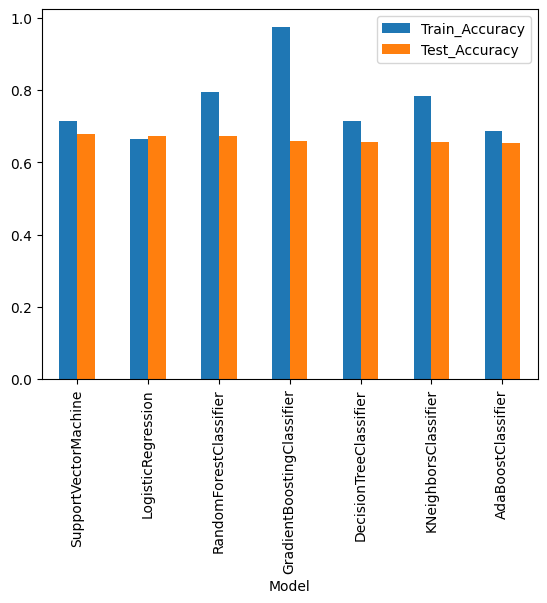

In [133]:
accurscy_df_sorted = accurscy_df.sort_values(by='Test_Accuracy', ascending=False)
plt.figure(figsize=(10, 6))
accurscy_df_sorted.plot(x='Model', y=['Train_Accuracy', 'Test_Accuracy'], kind='bar')
plt.show()

In [134]:
accurscy_df_sorted

,Model,Train_Accuracy,Test_Accuracy
2,SupportVectorMachine,0.714796,0.678054
0,LogisticRegression,0.663776,0.672878
4,RandomForestClassifier,0.795918,0.672878
6,GradientBoostingClassifier,0.975510,0.660455
3,DecisionTreeClassifier,0.713265,0.657350
1,KNeighborsClassifier,0.782653,0.655280
5,AdaBoostClassifier,0.685714,0.653209


In [135]:
#B. Select the final best trained model along with your detailed comments for selecting this model.
print("Best Model:", accurscy_df['Model'].loc[accurscy_df['Test_Accuracy'] == accurscy_df['Test_Accuracy'].max()])

Best Model: 2    SupportVectorMachine
Name: Model, dtype: object


**Conclusions:-**
1. The test accuracy are highest for "SupportVectorMachine" among all the classifier model used above.
2. Although if we consider more generalised model where there is minimum gap between train and test accuracy, then it is "LogisticRegression".
3. There is not much gap(1%) between train and test accuracy of best model and generalised model.
4. There is significant gap(10%) between train and test accuracy of best model and generalised model.
5. "GradientBoostingClassifier" has performed best with respect to train accuracy but test accuracy is low and the gap is more than 30%, which is not the characteristics of generalised model.

In [138]:
#C. Pickle the selected model for future use.
import pickle
# Open a file for writing in binary mode
with open('svm_final_model.pkl', 'wb') as f:
  pickle.dump(model, f)

print("Model pickled successfully!")

Model pickled successfully!


In [141]:
#D. Write your conclusion on the results.

**Conclusion:-**
1. "SupportVectorMachine" has performed the best test accuracy, It seems because of huge features in data set that are located in high dimentional space, and for this kind of data "SupportVectorMachine" is best.
2. As part of feture engineering droping of low variance feature and high VIF are done along with PCA.
3. Multiple cross-validation techniques has been used like "KFold", "LeaveOneOut" and "StratifiedKFold".
4. For hyperparameter tuning "GridSearchCV", "RandomizedSearchCV".